# GradDiff + Distillation Experiments


## 1. Environment Check

In [1]:
import os, sys, torch

# Make sure the repo root is on the path
REPO_DIR = os.path.abspath(os.path.join(os.path.dirname("__file__"), ".."))
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

# Read paths from env vars (set by jupyter.sbatch) with sensible fallbacks
WORKSPACE_DIR   = os.environ.get("WORKSPACE_DIR",    os.path.expanduser("~/workspace"))
CACHE_DIR       = os.environ.get("CACHE_DIR",        os.path.join(WORKSPACE_DIR, ".cache"))

print(f"REPO_DIR      = {REPO_DIR}")
print()
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
    print(f"VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

REPO_DIR      = /lustre/fsw/portfolios/sw/projects/sw_aidot/users/hsahota/cs338

PyTorch version : 2.4.0
CUDA available  : True
GPU             : NVIDIA H100 80GB HBM3
VRAM            : 84.9 GB


In [2]:
import shutil

# Remove all saved model checkpoints so every full run starts from scratch.
# This prevents stale weights from a previous partial run from being loaded.
models_dir = "./models"
if os.path.exists(models_dir):
    shutil.rmtree(models_dir)
    print(f"Cleaned up: removed '{models_dir}/'")
else:
    print(f"Nothing to clean ('{models_dir}/' does not exist).")


Cleaned up: removed './models/'


## 2. Project Imports

In [12]:
from torch.utils.data import DataLoader
from transformers import (
    AutoConfig, AutoModelForCausalLM, AutoTokenizer,
    TrainingArguments, Trainer, DataCollatorForLanguageModeling,
)
from datasets import load_dataset
from torch.optim import AdamW
from tqdm import tqdm
import torch.nn as nn
import torch.nn.functional as F
import importlib

# Project utilities
from src.utils.loss_functions import cross_entropy_loss_fn, forward_kl_loss_fn

import notebooks.helpers as _helpers_mod
importlib.reload(_helpers_mod)
from notebooks.helpers import calculate_perplexity, plot_relearning_curves, plot_retain_perplexity

import notebooks.distillation as _distill_mod
importlib.reload(_distill_mod)
from notebooks.distillation import DistillationDataset

from notebooks.unlearning import UnlearningDataset

print("All imports OK")


All imports OK


In [4]:
# ── Experiment Configuration ────────────────────────────────────────────────
# All dataset-size knobs live here.  Change these values and re-run the
# notebook top-to-bottom; every downstream cell picks them up automatically.

# TOFU split to forget — available: "forget01" (1 %), "forget05" (5 %), "forget10" (10 %)
TOFU_SPLIT = "forget10"

# Number of The Pile texts for capability-retention evaluation (Step 4)
RETAIN_EVAL_SAMPLES = 500

# Eval set is sampled from the start of The Pile.
# Step 2 and Step 3 both use TOFU splits (not The Pile), so no overlap to skip.
RETAIN_EVAL_SKIP = 0

print(f"TOFU split              : {TOFU_SPLIT}")
print(f"Distill data            : TOFU {TOFU_SPLIT} (forget) + retain complement")
print(f"Retain eval samples     : {RETAIN_EVAL_SAMPLES:,}")
print(f"Eval skip offset        : {RETAIN_EVAL_SKIP:,}")
print(f"Unlearn data            : TOFU {TOFU_SPLIT} (forget) + retain complement")

TOFU split              : forget10
Distill data            : TOFU forget10 (forget) + retain complement
Retain eval samples     : 500
Eval skip offset        : 0
Unlearn data            : TOFU forget10 (forget) + retain complement


## Experimental Approach (Appendix F Recipe)

Instead of pre-training from scratch (as the original paper does), we use a publicly available model and inject knowledge directly via fine-tuning.

### Core Recipe

1. **Fine-tune (Inject)** — Fine-tune a base Pythia model on a dataset it has never seen (e.g., the fictional biographical data in the TOFU benchmark). This simulates the "pre-training contamination" scenario from the paper.

2. **Unlearn (Suppress)** — Apply a baseline unlearning method (Gradient Difference, MaxEnt, or RMU) to suppress the injected knowledge.

3. **Distill (Robustify)** — Distill the unlearned model's outputs back into the student model. The distillation step repairs any collateral damage to general language modelling ability while reinforcing suppression of the forgotten knowledge.

---

### Additional Ideas

- **Impact of Training Age (Intermediate Checkpoints)** — Pythia provides 154 intermediate checkpoints per model size. Test whether distillation is more or less effective when starting from an early-stage checkpoint (e.g., step 10k) vs. the fully-trained final checkpoint.

- **Scale Frontier** — Evaluate whether larger Pythia models (e.g., 410M vs. 160M) retain stronger latent traces after unlearning, making distillation more critical as parameter count grows.

- **Quantization Vulnerability** — The paper shows that standard unlearning fails under INT4 quantization because numerical instability exposes latent structure. Run a post-training quantization check on Pythia models to test whether distillation completely neutralizes this attack vector.

In [5]:
# 1. Setup Device and Load Model/Tokenizer
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# You can swap this path with your localized, unlearned, or distilled model weights
model_name = "EleutherAI/pythia-160m" 
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)

# Pythia models do not have a pad token by default; use eos_token
tokenizer.pad_token = tokenizer.eos_token



Using device: cuda


# Step 1 - Finetune on Forget set

In [6]:

# Always reload so this cell is safe to re-run.
# Force float32: running the HF Trainer with bf16=True in a previous cell sets
# AcceleratorState to bf16 as a global singleton; without torch_dtype=float32
# the model inherits that and produces NaN in the backward pass.
print("Reloading base model for fine-tuning...")
model = AutoModelForCausalLM.from_pretrained(
    "EleutherAI/pythia-160m", torch_dtype=torch.float32
).to(device)

_RETAIN_MAP = {'forget01': 'retain99', 'forget05': 'retain95', 'forget10': 'retain90'}
ft_retain_split = _RETAIN_MAP[TOFU_SPLIT]

print(f"Loading TOFU {TOFU_SPLIT} (forget) + {ft_retain_split} (retain) for fine-tuning...")
forget_ds = load_dataset("locuslab/TOFU", TOFU_SPLIT)["train"]
retain_ds = load_dataset("locuslab/TOFU", ft_retain_split)["train"]

def tokenize_tofu_ft(examples):
    texts = [f"Question: {q}\nAnswer: {a}{tokenizer.eos_token}"
             for q, a in zip(examples["question"], examples["answer"])]
    return tokenizer(texts, truncation=True, max_length=256, padding=False)

# remove_columns is critical: DataCollatorForLanguageModeling does not handle
# raw string columns; leaving them in produces all-(-100) labels → loss = 0.
from datasets import concatenate_datasets
forget_tok_ft = forget_ds.map(tokenize_tofu_ft, batched=True, remove_columns=forget_ds.column_names)
retain_tok_ft = retain_ds.map(tokenize_tofu_ft, batched=True, remove_columns=retain_ds.column_names)
tokenized_dataset = concatenate_datasets([forget_tok_ft, retain_tok_ft])
print(f"Train examples : {len(tokenized_dataset)}  ({len(forget_tok_ft)} forget + {len(retain_tok_ft)} retain)")

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)
train_loader = DataLoader(tokenized_dataset, batch_size=4, shuffle=True,
                          collate_fn=data_collator)

epochs = 5
lr = 2e-5
max_grad_norm = 1.0
optimizer = AdamW(model.parameters(), lr=lr, weight_decay=0.01)
output_dir = "./models/pythia-160m-finetuned-tofu"
os.makedirs(output_dir, exist_ok=True)

print("Starting Step 1 Fine-Tuning Loop...")
model.train()
for epoch in range(epochs):
    epoch_loss = 0.0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        optimizer.zero_grad()
        outputs = model(
            input_ids=batch["input_ids"].to(device),
            attention_mask=batch["attention_mask"].to(device),
            labels=batch["labels"].to(device),
        )
        loss = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(train_loader)
    print(f"Epoch {epoch+1} | Avg Loss: {avg_loss:.4f}")

model.save_pretrained(output_dir)
tokenizer.save_pretrained(output_dir)
print(f"\n[Success] Step 1 complete. Model saved to: '{output_dir}'")


`torch_dtype` is deprecated! Use `dtype` instead!


Reloading base model for fine-tuning...
Loading TOFU forget10 (forget) + retain90 (retain) for fine-tuning...
Train examples : 4000  (400 forget + 3600 retain)
Starting Step 1 Fine-Tuning Loop...


Epoch 1: 100%|██████████| 1000/1000 [00:20<00:00, 48.01it/s]


Epoch 1 | Avg Loss: 2.1807


Epoch 2: 100%|██████████| 1000/1000 [00:20<00:00, 48.63it/s]


...

Epoch 3 | Avg Loss: 1.3933


Epoch 4: 100%|██████████| 1000/1000 [00:20<00:00, 48.59it/s]


Epoch 4 | Avg Loss: 1.1822


Epoch 5: 100%|██████████| 1000/1000 [00:20<00:00, 48.89it/s]


Epoch 5 | Avg Loss: 1.0204

[Success] Step 1 complete. Model saved to: './models/pythia-160m-finetuned-tofu'


# Step 2: Unlearn using Gradient Difference

In [7]:

# Load the fine-tuned model from Step 1 as the starting point for unlearning
# torch_dtype=float32: same bf16 AcceleratorState issue applies here.
unlearn_model = AutoModelForCausalLM.from_pretrained(
    "./models/pythia-160m-finetuned-tofu", torch_dtype=torch.float32
).to(device)

# --- FORGET SET: same TOFU split used in Step 1 ---
forget_dataset = load_dataset("locuslab/TOFU", TOFU_SPLIT)

_RETAIN_MAP = {'forget01': 'retain99', 'forget05': 'retain95', 'forget10': 'retain90'}
unlearn_retain_split = _RETAIN_MAP[TOFU_SPLIT]
retain_dataset = load_dataset("locuslab/TOFU", unlearn_retain_split)

def tokenize_tofu(examples):
    texts = [f"Question: {q}\nAnswer: {a}{tokenizer.eos_token}"
             for q, a in zip(examples["question"], examples["answer"])]
    return tokenizer(texts, truncation=True, max_length=256, padding=False)

# NOTE: No set_format("torch") — DataCollatorForLanguageModeling handles tensor
# conversion internally. Pre-tensorizing via set_format causes all-(-100) labels.
forget_tok = forget_dataset["train"].map(tokenize_tofu, batched=True,
                                          remove_columns=forget_dataset["train"].column_names)
retain_tok = retain_dataset["train"].map(tokenize_tofu, batched=True,
                                          remove_columns=retain_dataset["train"].column_names)

print(f"Forget set size : {len(forget_tok)} (TOFU {TOFU_SPLIT})")
print(f"Retain set size : {len(retain_tok)} (TOFU {unlearn_retain_split})")

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)
forget_loader = DataLoader(forget_tok, batch_size=4, shuffle=True, collate_fn=data_collator)
retain_loader = DataLoader(retain_tok, batch_size=4, shuffle=True, collate_fn=data_collator)

# Hyperparameters
epochs = 3
lr = 5e-6
beta = 1.0       # weight on retain loss
max_grad_norm = 1.0  # clamp gradients — critical for gradient ascent stability

optimizer = AdamW(unlearn_model.parameters(), lr=lr)

print("Starting Gradient Difference Unlearning...")
unlearn_model.train()

for epoch in range(epochs):
    retain_iter = iter(retain_loader)
    for forget_batch in tqdm(forget_loader, desc=f"Epoch {epoch+1}"):
        try:
            retain_batch = next(retain_iter)
        except StopIteration:
            retain_iter = iter(retain_loader)
            retain_batch = next(retain_iter)

        optimizer.zero_grad()

        forget_outputs = unlearn_model(input_ids=forget_batch["input_ids"].to(device),
                                       attention_mask=forget_batch["attention_mask"].to(device),
                                       labels=forget_batch["labels"].to(device))
        forget_loss = forget_outputs.loss

        retain_outputs = unlearn_model(input_ids=retain_batch["input_ids"].to(device),
                                       attention_mask=retain_batch["attention_mask"].to(device),
                                       labels=retain_batch["labels"].to(device))
        retain_loss = retain_outputs.loss

        # Gradient Difference: ascend on forget, descend on retain
        total_loss = -forget_loss + beta * retain_loss
        total_loss.backward()

        # Clip gradients — gradient ascent can easily explode without this,
        # producing NaN weights that break the downstream distillation step.
        torch.nn.utils.clip_grad_norm_(unlearn_model.parameters(), max_grad_norm)

        optimizer.step()

    print(f"Epoch {epoch+1} | Forget Loss: {forget_loss.item():.4f} | Retain Loss: {retain_loss.item():.4f}")

unlearn_model.save_pretrained("./models/pythia-160m-unlearned")

tokenizer.save_pretrained("./models/pythia-160m-unlearned")
print("Unlearned model saved to: './models/pythia-160m-unlearned'")


Map:   0%|          | 0/3600 [00:00<?, ? examples/s]

Forget set size : 400 (TOFU forget10)
Retain set size : 3600 (TOFU retain90)
Starting Gradient Difference Unlearning...


Epoch 1: 100%|██████████| 100/100 [00:03<00:00, 28.55it/s]


Epoch 1 | Forget Loss: 2.3284 | Retain Loss: 1.0621


Epoch 2: 100%|██████████| 100/100 [00:03<00:00, 29.10it/s]


Epoch 2 | Forget Loss: 29.9545 | Retain Loss: 6.8101


Epoch 3: 100%|██████████| 100/100 [00:03<00:00, 29.38it/s]


Epoch 3 | Forget Loss: 133.9794 | Retain Loss: 2.9926
Unlearned model saved to: './models/pythia-160m-unlearned'


# Step 3: Distillation

### Method

**Models**
- **Teacher** — the gradient-difference unlearned model from Step 2. It runs frozen (no gradients) and provides soft supervision.
- **Student** — a *noised* copy of the same unlearned model. Gaussian noise is injected directly into every weight tensor before training begins.

**Key idea**: standard unlearning suppresses a model's ability to *output* forgotten knowledge, but latent traces may remain encoded in the weights and can be recovered by a relearning attack or fine-tuning. Adding weight noise disrupts these residual traces. The subsequent distillation step then repairs any collateral damage to general language modelling ability by aligning the student back toward the (unlearned) teacher's output distribution on general text.

**Data**: TOFU forget + retain splits (same corpus used for fine-tuning and unlearning). The forget-set questions expose the teacher's suppressed outputs directly to the student; the retain-set questions provide positive capability signal on authors the model should still know.

**Loss**: a 50/50 mixture of two terms computed at every token position:

$$\mathcal{L} = \underbrace{\frac{1}{2} \mathcal{L}_{\text{CE}}}_{\text{language modelling}} + \underbrace{\frac{1}{2} T^2 \cdot D_{\text{KL}}\!\left(p_\theta^{(T)} \,\|\, p_\phi\right)}_{\text{imitation of teacher}}$$

- $\mathcal{L}_{\text{CE}}$ — standard next-token cross-entropy against ground-truth labels. Keeps the student a coherent language model.
- $D_{\text{KL}}$ — KL divergence from the soft teacher distribution to the student. Temperature $T=2$ spreads probability mass and transfers uncertainty rather than just the argmax; the $T^2$ factor rescales the gradient magnitude.

**Why noise + distill removes traces**: weight noise randomises the precise weight configurations that encode latent knowledge. Because that knowledge requires coordinated activations across many layers, even small perturbations are enough to break the structure while leaving general fluency largely intact. Distillation on general text then restores fluency without reintroducing the forgotten knowledge, since the teacher itself does not produce it.


In [8]:

# Load Teacher and Student models
print("Loading Teacher and Student models...")

# Teacher = the already-unlearned model (frozen).
# Supplies a distribution where the forgotten knowledge is behaviourally suppressed.
teacher_model = AutoModelForCausalLM.from_pretrained(
    "./models/pythia-160m-unlearned", torch_dtype=torch.float32
).to(device)
teacher_model.eval()

# Student = the original base checkpoint (before Step 1 fine-tuning).
# Starting from the pre-fine-tuning weights means the student has never seen
# the TOFU forget-set authors, so there are no latent traces to worry about.
# Distillation on the TOFU corpus then shapes the student to match the
# teacher's (already-suppressed) output distribution.
student_model = AutoModelForCausalLM.from_pretrained(
    "EleutherAI/pythia-160m", torch_dtype=torch.float32
).to(device)
student_model.train()

# Sanity-check teacher for NaN weights (caused by unclipped gradient ascent in Step 2)
nan_params = [n for n, p in teacher_model.named_parameters() if torch.isnan(p).any()]
if nan_params:
    print(f"WARNING: teacher model has NaN weights ({len(nan_params)} tensors). Re-run Step 2 with grad clipping.")
else:
    print("Teacher weights OK (no NaN).")

# --- DISTILLATION DATA: TOFU forget + retain ---
# forget split: teacher's suppressed outputs teach the student to reproduce
#               that suppression directly on the forgotten questions.
# retain split: positive capability signal on the authors still to be known.
_RETAIN_MAP = {'forget01': 'retain99', 'forget05': 'retain95', 'forget10': 'retain90'}
distill_retain_split = _RETAIN_MAP[TOFU_SPLIT]

def _tofu_distill_texts(split):
    ds = load_dataset("locuslab/TOFU", split)["train"]
    return [f"Question: {q}\nAnswer: {a}{tokenizer.eos_token}"
            for q, a in zip(ds["question"], ds["answer"])]

forget_distill_texts = _tofu_distill_texts(TOFU_SPLIT)
retain_distill_texts = _tofu_distill_texts(distill_retain_split)
distill_texts = forget_distill_texts + retain_distill_texts
print(f"Distillation forget texts : {len(forget_distill_texts)} (TOFU {TOFU_SPLIT})")
print(f"Distillation retain texts : {len(retain_distill_texts)} (TOFU {distill_retain_split})")
print(f"Distillation total        : {len(distill_texts)}")

distill_tok_raw = tokenizer(distill_texts, truncation=True, max_length=256,
                            padding=False, return_tensors=None)

from datasets import Dataset as HFDataset
distill_tok = HFDataset.from_dict({
    "input_ids":      distill_tok_raw["input_ids"],
    "attention_mask": distill_tok_raw["attention_mask"],
})

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)
distill_loader = DataLoader(distill_tok, batch_size=4, shuffle=True, collate_fn=data_collator)

# Hyperparameters & Optimizer
epochs = 3
lr = 5e-6
temperature = 2.0
max_grad_norm = 1.0
optimizer = AdamW(student_model.parameters(), lr=lr)

# Core Distillation Loop
print("Starting Distillation Phase...")
for epoch in range(epochs):
    epoch_loss = 0.0
    valid_steps = 0
    for batch in tqdm(distill_loader, desc=f"Epoch {epoch+1}"):
        optimizer.zero_grad()

        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"].to(device)

        # Teacher pass (frozen)
        with torch.no_grad():
            teacher_logits = teacher_model(input_ids=input_ids,
                                           attention_mask=attention_mask).logits

        # Student pass
        student_outputs  = student_model(input_ids=input_ids,
                                         attention_mask=attention_mask,
                                         labels=labels)
        student_logits   = student_outputs.logits
        standard_ce_loss = student_outputs.loss

        # KL divergence (temperature-scaled)
        B, T, V = teacher_logits.shape
        t_flat = teacher_logits.view(B * T, V)
        s_flat = student_logits.view(B * T, V)
        soft_teacher_probs     = F.softmax(t_flat / temperature, dim=-1).clamp(min=1e-10)
        soft_student_log_probs = F.log_softmax(s_flat / temperature, dim=-1)
        kl_loss = F.kl_div(soft_student_log_probs, soft_teacher_probs,
                           reduction="batchmean") * (temperature ** 2)

        total_loss = 0.5 * standard_ce_loss + 0.5 * kl_loss

        if torch.isnan(total_loss):
            print(f"  NaN skipped (CE={standard_ce_loss.item():.4f}, KL={kl_loss.item():.4f})")
            continue

        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(student_model.parameters(), max_grad_norm)
        optimizer.step()
        epoch_loss += total_loss.item()
        valid_steps += 1

    avg = epoch_loss / valid_steps if valid_steps > 0 else float("nan")
    print(f"Epoch {epoch+1} Complete | Avg Loss: {avg:.4f}  ({valid_steps}/{len(distill_loader)} valid batches)")

# Save the final distilled model
student_model.save_pretrained("./models/pythia-160m-distilled")
tokenizer.save_pretrained("./models/pythia-160m-distilled")
print("Distilled model saved to: './models/pythia-160m-distilled'")


Loading Teacher and Student models...
Teacher weights OK (no NaN).
Distillation forget texts : 400 (TOFU forget10)
Distillation retain texts : 3600 (TOFU retain90)
Distillation total        : 4000
Starting Distillation Phase...


Epoch 1: 100%|██████████| 1000/1000 [00:26<00:00, 37.84it/s]


Epoch 1 Complete | Avg Loss: 3.2542  (1000/1000 valid batches)


Epoch 2: 100%|██████████| 1000/1000 [00:26<00:00, 37.47it/s]


Epoch 2 Complete | Avg Loss: 2.2779  (1000/1000 valid batches)


Epoch 3: 100%|██████████| 1000/1000 [00:26<00:00, 37.93it/s]


Epoch 3 Complete | Avg Loss: 1.9623  (1000/1000 valid batches)
Distilled model saved to: './models/pythia-160m-distilled'


Loading retain-set eval texts from TOFU retain90...
  Loaded 500 retain texts (TOFU retain90).
Building forget-set eval texts from TOFU forget10...
  Loaded 400 forget texts.

Loading model variants for evaluation...

Computing retain-set perplexity on TOFU retain90 (lower is better)...
  Vanilla base model          : PPL = 27.76
  Fine-tuned model            : PPL = 3.09
  GradDiff unlearned model    : PPL = 287.12
  Distilled model             : PPL = 6.41

--- Capability Degradation (vs Fine-tuned) ---
  Unlearned : Δ PPL = +284.03  (+9184.8%)
  Distilled : Δ PPL = +3.32  (+107.3%)

[Success] Chart saved as 'retain_perplexity.png'


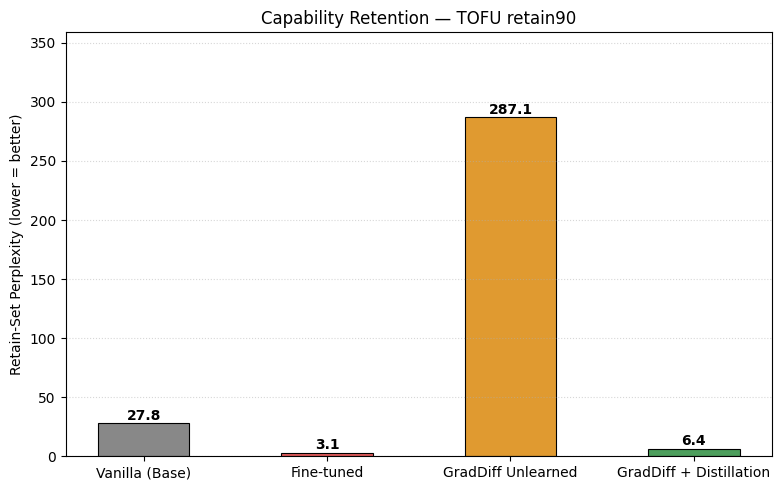


Computing forget-set (TOFU) perplexity (higher is better — means the model forgot)...
  Vanilla base model          : PPL = 27.38  ← ideal ceiling (never learned TOFU)
  Fine-tuned model            : PPL = 2.83  ← lower bound (fully learned TOFU)
  GradDiff unlearned model    : PPL = 255671870916328330301636829463431790870594097485509159813120.00
  Distilled model             : PPL = 56.46

Forget-set PPL plot y-axis capped at 84.7  (GradDiff unlearned = 255671870916328330301636829463431790870594097485509159813120.0, shown clipped)

[Success] Chart saved as 'forget_perplexity.png'


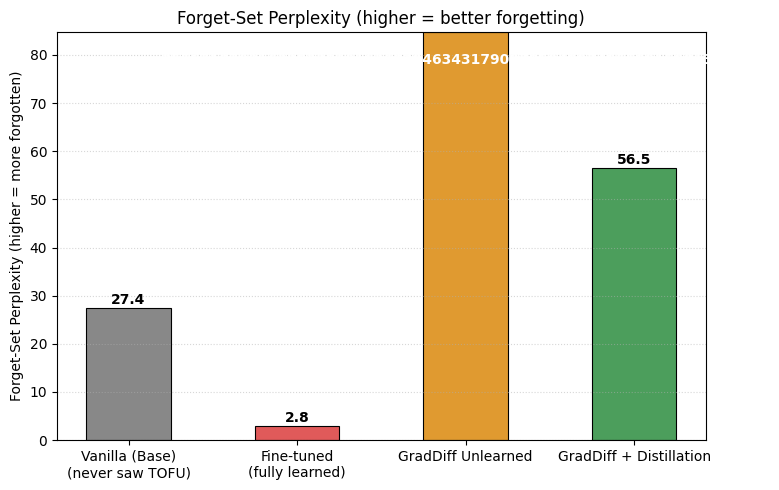

Evaluation models freed from memory.


In [13]:
# Step 4: Capability Retention & Forget-Set Evaluation
# Two bar charts:
#   (a) Retain-set (TOFU retain90) perplexity — lower is better; measures how much
#       general language-modeling ability was preserved after unlearning/distillation.
#   (b) Forget-set (TOFU forget10) perplexity — higher is better; measures how
#       thoroughly the model has forgotten the injected knowledge.
#       The vanilla base model (never fine-tuned on TOFU) is the ideal ceiling.
#
# NOTE: models are loaded fresh from disk here, BEFORE the relearning attack
# (Step 5) mutates them.

_RETAIN_MAP = {'forget01': 'retain99', 'forget05': 'retain95', 'forget10': 'retain90'}
eval_retain_split = _RETAIN_MAP[TOFU_SPLIT]

print(f"Loading retain-set eval texts from TOFU {eval_retain_split}...")
tofu_retain_eval_ds = load_dataset("locuslab/TOFU", eval_retain_split)["train"]
retain_eval_texts = [
    f"Question: {q}\nAnswer: {a}{tokenizer.eos_token}"
    for q, a in zip(tofu_retain_eval_ds["question"], tofu_retain_eval_ds["answer"])
]
# Cap at RETAIN_EVAL_SAMPLES to keep eval time reasonable
retain_eval_texts = retain_eval_texts[:RETAIN_EVAL_SAMPLES]
print(f"  Loaded {len(retain_eval_texts)} retain texts (TOFU {eval_retain_split}).")

# Build forget-set eval texts from TOFU (same format used during fine-tuning)
print(f"Building forget-set eval texts from TOFU {TOFU_SPLIT}...")
tofu_eval_ds = load_dataset("locuslab/TOFU", TOFU_SPLIT)
forget_eval_texts = [
    f"Question: {q}\nAnswer: {a}{tokenizer.eos_token}"
    for q, a in zip(tofu_eval_ds["train"]["question"], tofu_eval_ds["train"]["answer"])
]
print(f"  Loaded {len(forget_eval_texts)} forget texts.")

# Load each model variant fresh from disk
print("\nLoading model variants for evaluation...")
eval_vanilla    = AutoModelForCausalLM.from_pretrained(
    "EleutherAI/pythia-160m", torch_dtype=torch.float32).to(device)
eval_finetuned  = AutoModelForCausalLM.from_pretrained(
    "./models/pythia-160m-finetuned-tofu", torch_dtype=torch.float32).to(device)
eval_unlearned  = AutoModelForCausalLM.from_pretrained(
    "./models/pythia-160m-unlearned", torch_dtype=torch.float32).to(device)
eval_distilled  = AutoModelForCausalLM.from_pretrained(
    "./models/pythia-160m-distilled", torch_dtype=torch.float32).to(device)

# ── (a) Retain-set perplexity ───────────────────────────────────────────────
print(f"\nComputing retain-set perplexity on TOFU {eval_retain_split} (lower is better)...")
ppl_vanilla   = calculate_perplexity(eval_vanilla,   tokenizer, retain_eval_texts, device)
print(f"  Vanilla base model          : PPL = {ppl_vanilla:.2f}")
ppl_finetuned = calculate_perplexity(eval_finetuned, tokenizer, retain_eval_texts, device)
print(f"  Fine-tuned model            : PPL = {ppl_finetuned:.2f}")
ppl_unlearned = calculate_perplexity(eval_unlearned, tokenizer, retain_eval_texts, device)
print(f"  GradDiff unlearned model    : PPL = {ppl_unlearned:.2f}")
ppl_distilled = calculate_perplexity(eval_distilled, tokenizer, retain_eval_texts, device)
print(f"  Distilled model             : PPL = {ppl_distilled:.2f}")

print("\n--- Capability Degradation (vs Fine-tuned) ---")
print(f"  Unlearned : Δ PPL = {ppl_unlearned - ppl_finetuned:+.2f}  "
      f"({(ppl_unlearned / ppl_finetuned - 1) * 100:+.1f}%)")
print(f"  Distilled : Δ PPL = {ppl_distilled - ppl_finetuned:+.2f}  "
      f"({(ppl_distilled / ppl_finetuned - 1) * 100:+.1f}%)")

plot_retain_perplexity(
    labels       = ["Vanilla (Base)", "Fine-tuned", "GradDiff Unlearned", "GradDiff + Distillation"],
    perplexities = [ppl_vanilla, ppl_finetuned, ppl_unlearned, ppl_distilled],
    filename     = "retain_perplexity.png",
    title        = f"Capability Retention — TOFU {eval_retain_split}",
    ylabel       = "Retain-Set Perplexity (lower = better)",
)

# ── (b) Forget-set perplexity ───────────────────────────────────────────────
print("\nComputing forget-set (TOFU) perplexity (higher is better — means the model forgot)...")
fppl_vanilla   = calculate_perplexity(eval_vanilla,   tokenizer, forget_eval_texts, device)
print(f"  Vanilla base model          : PPL = {fppl_vanilla:.2f}  ← ideal ceiling (never learned TOFU)")
fppl_finetuned = calculate_perplexity(eval_finetuned, tokenizer, forget_eval_texts, device)
print(f"  Fine-tuned model            : PPL = {fppl_finetuned:.2f}  ← lower bound (fully learned TOFU)")
fppl_unlearned = calculate_perplexity(eval_unlearned, tokenizer, forget_eval_texts, device)
print(f"  GradDiff unlearned model    : PPL = {fppl_unlearned:.2f}")
fppl_distilled = calculate_perplexity(eval_distilled, tokenizer, forget_eval_texts, device)
print(f"  Distilled model             : PPL = {fppl_distilled:.2f}")

# The GradDiff unlearned model has runaway forget-set PPL (gradient ascent pushes
# it into the thousands).  Cap the y-axis so the comparison between vanilla,
# fine-tuned, and distilled is readable.  Clipped bars are annotated with their
# true value + ↑ so the reader still sees the magnitude.
_forget_ylim = (0, max(fppl_vanilla, fppl_finetuned, fppl_distilled) * 1.5)
print(f"\nForget-set PPL plot y-axis capped at {_forget_ylim[1]:.1f}  "
      f"(GradDiff unlearned = {fppl_unlearned:.1f}, shown clipped)")
plot_retain_perplexity(
    labels       = ["Vanilla (Base)\n(never saw TOFU)", "Fine-tuned\n(fully learned)", "GradDiff Unlearned", "GradDiff + Distillation"],
    perplexities = [fppl_vanilla, fppl_finetuned, fppl_unlearned, fppl_distilled],
    filename     = "forget_perplexity.png",
    title        = "Forget-Set Perplexity (higher = better forgetting)",
    ylabel       = "Forget-Set Perplexity (higher = more forgotten)",
    ylim         = _forget_ylim,
)

# Free evaluation copies from GPU memory before the relearning attack
del eval_vanilla, eval_finetuned, eval_unlearned, eval_distilled
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("Evaluation models freed from memory.")


In [59]:
!pwd

/lustre/fsw/portfolios/sw/projects/sw_aidot/users/hsahota/cs338/MSandE338


Loading models for relearning evaluation...
Running relearning attack for 50 gradient steps on each model (seed=42)...
  Vanilla base model...


  Standard unlearned model...


  Distilled model...



[Success] Chart saved as 'relearning_attack_results.png'


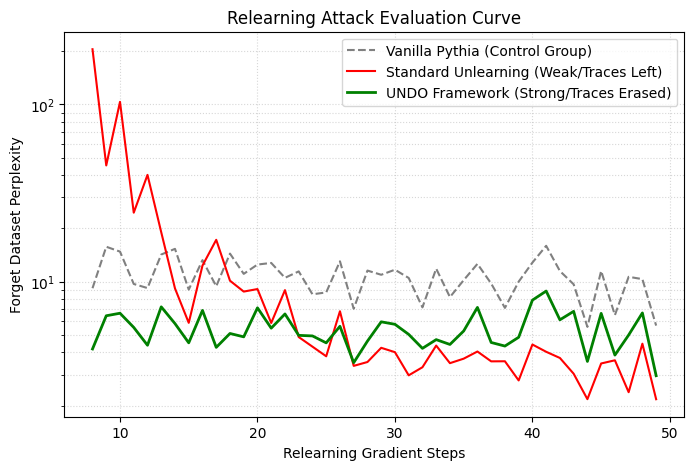

In [19]:
# Step 5: Relearning Attack Evaluation
# Measures how quickly each model variant re-learns the forgotten TOFU data.
# A distilled model should be as hard to re-teach as the vanilla base model.

# Fix all random seeds so the learning curves are reproducible across re-runs.
# Without this, shuffle=True in the DataLoader and PyTorch's internal RNG
# produce a different batch order and different curves every time.
RELEARN_SEED = 42
torch.manual_seed(RELEARN_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RELEARN_SEED)
import random, numpy as np
random.seed(RELEARN_SEED)
np.random.seed(RELEARN_SEED)

print("Loading models for relearning evaluation...")
vanilla_model      = AutoModelForCausalLM.from_pretrained(
    "EleutherAI/pythia-160m", torch_dtype=torch.float32).to(device)
standard_unlearned = AutoModelForCausalLM.from_pretrained(
    "./models/pythia-160m-unlearned", torch_dtype=torch.float32).to(device)
distilled_model    = AutoModelForCausalLM.from_pretrained(
    "./models/pythia-160m-distilled", torch_dtype=torch.float32).to(device)

# Tokenize TOFU forget split for the relearning attack
relearn_dataset = load_dataset("locuslab/TOFU", TOFU_SPLIT)

def tokenize_tofu_relearn(examples):
    texts = [f"Question: {q}\nAnswer: {a}{tokenizer.eos_token}"
             for q, a in zip(examples["question"], examples["answer"])]
    return tokenizer(texts, truncation=True, max_length=256, padding=False)

relearn_tok = relearn_dataset["train"].map(
    tokenize_tofu_relearn, batched=True,
    remove_columns=relearn_dataset["train"].column_names,
)
relearn_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

def make_relearn_loader():
    """Return a freshly-seeded DataLoader so each model sees the same batch order."""
    g = torch.Generator()
    g.manual_seed(RELEARN_SEED)
    return DataLoader(relearn_tok, batch_size=4, shuffle=True,
                      collate_fn=relearn_collator, generator=g)


def run_relearning(m, loader, steps=50, lr=2e-5):
    """Fine-tune model on forget set; return per-step perplexity (exp of per-token CE loss)."""
    import math
    m.train()
    opt       = AdamW(m.parameters(), lr=lr)
    ppls      = []
    data_iter = iter(loader)
    for _ in tqdm(range(steps), leave=False):
        try:
            batch = next(data_iter)
        except StopIteration:
            data_iter = iter(loader)
            batch = next(data_iter)
        opt.zero_grad()
        out = m(
            input_ids=batch["input_ids"].to(device),
            attention_mask=batch["attention_mask"].to(device),
            labels=batch["labels"].to(device),
        )
        out.loss.backward()
        torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)
        opt.step()
        ppls.append(math.exp(out.loss.item()))
    return ppls


RELEARN_STEPS = 50
print(f"Running relearning attack for {RELEARN_STEPS} gradient steps on each model "
      f"(seed={RELEARN_SEED})...")

print("  Vanilla base model...")
vanilla_ppls   = run_relearning(vanilla_model,      make_relearn_loader(), steps=RELEARN_STEPS)
print("  Standard unlearned model...")
standard_ppls  = run_relearning(standard_unlearned, make_relearn_loader(), steps=RELEARN_STEPS)
print("  Distilled model...")
distilled_ppls = run_relearning(distilled_model,    make_relearn_loader(), steps=RELEARN_STEPS)


# Skip the first PLOT_SKIP steps when plotting: the unlearned and distilled
# curves start at very high perplexity (models haven't seen the forget set yet),
# which compresses the interesting convergence behaviour in the later steps.
# All steps are still *trained*; we're only zooming the x-axis of the plot.
PLOT_SKIP  = 8
steps_axis = list(range(PLOT_SKIP, RELEARN_STEPS))
plot_relearning_curves(
    steps_axis,
    vanilla_ppls[PLOT_SKIP:],
    standard_ppls[PLOT_SKIP:],
    distilled_ppls[PLOT_SKIP:],
)


In [20]:
print("Loading final distilled model for generation...")
print(model_name)
final_model = AutoModelForCausalLM.from_pretrained(
    model_name, torch_dtype=torch.float32
).to(device)
# final_model = AutoModelForCausalLM.from_pretrained(
#     "./models/pythia-160m-distilled", torch_dtype=torch.float32
# ).to(device)
# final_model.eval()

prompts = [
    "Question: Who is Albert Einstein?\nAnswer:",
    "Question: What is the capital of France?\nAnswer:",
    "Once upon a time",
]

for i, prompt in enumerate(prompts, 1):
    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = final_model.generate(
            **inputs,
            max_new_tokens=80,
            do_sample=True,
            temperature=0.8,
            top_p=0.95,
            pad_token_id=tokenizer.eos_token_id,
        )

    text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    print(f"\n--- Sample {i} ---")
    print(text)

Loading final distilled model for generation...
EleutherAI/pythia-160m

--- Sample 1 ---
Question: Who is Albert Einstein?
Answer: A doctor from the United States. The answer is very good.

I don't know where you live but I can show you some pictures from the trip. I am from New York and I have a house near my parents' place. It is about an hour from the airport.

"I have a house in New York. I have a house in the city, and I live

--- Sample 2 ---
Question: What is the capital of France?
Answer: We will have to go to Italy.

A:

There are two different ways to answer this question. One is to define a capital city: a capital city is the capital of a city that is located in the country where it was created.
The other way is to define the capital city: a city is the city of a city that is located in a country with an abundance

--- Sample 3 ---
Once upon a time, I’m sure I’ll get lucky again.”

I don’t know what I would have done with a new game: A good story or a long-lasting campaign. 